# HW2 – Desenfoque gaussiano (Gaussian Blur) en CUDA
Introduction to Parallel Programming (Udacity CS344).

Se implementan en GPU: separación de una imagen RGBA en sus tres canales de color (Array of Structures -> Structure of Arrays) y la convolución con un filtro gaussiano, con manejo de bordes por clamping.

**Antes de empezar:** Entorno de ejecución -> Cambiar tipo de entorno -> **GPU (T4)**. Luego Entorno de ejecución -> Ejecutar todas.


In [1]:
!nvidia-smi


Thu Oct  1 12:51:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Instalar OpenCV (para leer y guardar imágenes)
Tarda uno o dos minutos.


In [2]:
!apt-get -qq update > /dev/null && apt-get -qq install -y libopencv-dev pkg-config > /dev/null && echo 'OpenCV instalado:' && pkg-config --modversion opencv4


W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
OpenCV instalado:
4.6.0


## 2. Clonar el repositorio, fijar la arquitectura de la T4 y adaptar el código a OpenCV 4
El código original usa constantes de OpenCV 2 (`CV_LOAD_IMAGE_COLOR`, `CV_BGR2RGBA`, `CV_RGBA2BGR`) que ya no existen; se reemplazan por sus equivalentes actuales. También se ajustan las flags de `nvcc` en el `CMakeLists.txt` para compilar para la GPU T4 (`sm_75`) que da Colab.


In [3]:
import os, re
%cd /content
!rm -rf udacity-cs344-colab
!git clone -q https://github.com/depctg/udacity-cs344-colab.git
%cd /content/udacity-cs344-colab

# Compilar para la T4 (sm_75)
p = 'src/CMakeLists.txt'
s = open(p).read()
s = re.sub(r'set\(CUDA_NVCC_FLAGS ".*?"\)',
           'set(CUDA_NVCC_FLAGS "-gencode;arch=compute_75,code=sm_75")', s, flags=re.S)
open(p, 'w').write(s)

# Constantes de OpenCV 4 (HW2.cpp usa nombres de OpenCV 2 que ya no existen)
!sed -i -E 's/CV_LOAD_IMAGE_COLOR/cv::IMREAD_COLOR/g; s/CV_LOAD_IMAGE_GRAYSCALE/cv::IMREAD_GRAYSCALE/g; s/\bCV_([A-Z]+)2([A-Z]+)\b/cv::COLOR_\12\2/g' src/HW2/*.cpp

!mkdir -p build
%cd build
!cmake ../src > /dev/null && echo 'CMake OK'


/content
/content/udacity-cs344-colab
/content/udacity-cs344-colab/build
CMake Deprecation Warning at CMakeLists.txt:8 (cmake_minimum_required):
  Compatibility with CMake < 3.10 will be removed from a future version of
  CMake.

  Update the VERSION argument <min> value.  Or, use the <min>...<max> syntax
  to tell CMake that the project requires at least <min> but has been updated
  to work with policies introduced by <max> or earlier.


CMake Warning (dev) at CMakeLists.txt:12 (find_package):
  Policy CMP0146 is not set: The FindCUDA module is removed.  Run "cmake
  --help-policy CMP0146" for policy details.  Use the cmake_policy command to
  set the policy and suppress this warning.

This warning is for project developers.  Use -Wno-dev to suppress it.

CMake Deprecation Warning at HW3/CMakeLists.txt:8 (cmake_minimum_required):
  Compatibility with CMake < 3.10 will be removed from a future version of
  CMake.

  Update the VERSION argument <min> value.  Or, use the <min>...<max> sy

## 3. Código


In [4]:
%%writefile /content/udacity-cs344-colab/src/HW2/student_func.cu
// Homework 2
// Image Blurring
//
// In this homework we are blurring an image. To do this, imagine that we have
// a square array of weight values. For each pixel in the image, imagine that we
// overlay this square array of weights on top of the image such that the center
// of the weight array is aligned with the current pixel. To compute a blurred
// pixel value, we multiply each pair of numbers that line up. In other words, we
// multiply each weight with the pixel underneath it. Finally, we add up all of the
// multiplied numbers and assign that value to our output for the current pixel.
// We repeat this process for all the pixels in the image.

// To help get you started, we have included some useful notes here.

//****************************************************************************

// For a color image that has multiple channels, we suggest separating
// the different color channels so that each color is stored contiguously
// instead of being interleaved. This will simplify your code.

// That is instead of RGBARGBARGBARGBA... we suggest transforming to three
// arrays (as in the previous homework we ignore the alpha channel again):
//  1) RRRRRRRR...
//  2) GGGGGGGG...
//  3) BBBBBBBB...
//
// The original layout is known an Array of Structures (AoS) whereas the
// format we are converting to is known as a Structure of Arrays (SoA).

// As a warm-up, we will ask you to write the kernel that performs this
// separation. You should then write the "meat" of the assignment,
// which is the kernel that performs the actual blur. We provide code that
// re-combines your blurred results for each color channel.

//****************************************************************************

// You must fill in the gaussian_blur kernel to perform the blurring of the
// inputChannel, using the array of weights, and put the result in the outputChannel.

// Here is an example of computing a blur, using a weighted average, for a single
// pixel in a small image.
//
// Array of weights:
//
//  0.0  0.2  0.0
//  0.2  0.2  0.2
//  0.0  0.2  0.0
//
// Image (note that we align the array of weights to the center of the box):
//
//    1  2  5  2  0  3
//       -------
//    3 |2  5  1| 6  0       0.0*2 + 0.2*5 + 0.0*1 +
//      |       |
//    4 |3  6  2| 1  4   ->  0.2*3 + 0.2*6 + 0.2*2 +   ->  3.2
//      |       |
//    0 |4  0  3| 4  2       0.0*4 + 0.2*0 + 0.0*3
//       -------
//    9  6  5  0  3  9
//
//         (1)                         (2)                 (3)
//
// A good starting place is to map each thread to a pixel as you have before.
// Then every thread can perform steps 2 and 3 in the diagram above
// completely independently of one another.

// Note that the array of weights is square, so its height is the same as its width.
// We refer to the array of weights as a filter, and we refer to its width with the
// variable filterWidth.

//****************************************************************************

// Your homework submission will be evaluated based on correctness and speed.
// We test each pixel against a reference solution. If any pixel differs by
// more than some small threshold value, the system will tell you that your
// solution is incorrect, and it will let you try again.

// Once you have gotten that working correctly, then you can think about using
// shared memory and having the threads cooperate to achieve better performance.

//****************************************************************************

// Also note that we've supplied a helpful debugging function called checkCudaErrors.
// You should wrap your allocation and copying statements like we've done in the
// code we're supplying you. Here is an example of the unsafe way to allocate
// memory on the GPU:
//
// cudaMalloc(&d_red, sizeof(unsigned char) * numRows * numCols);
//
// Here is an example of the safe way to do the same thing:
//
// checkCudaErrors(cudaMalloc(&d_red, sizeof(unsigned char) * numRows * numCols));
//
// Writing code the safe way requires slightly more typing, but is very helpful for
// catching mistakes. If you write code the unsafe way and you make a mistake, then
// any subsequent kernels won't compute anything, and it will be hard to figure out
// why. Writing code the safe way will inform you as soon as you make a mistake.

// Finally, remember to free the memory you allocate at the end of the function.

//****************************************************************************

#include "utils.h"

__global__
void gaussian_blur(const unsigned char* const inputChannel,
                   unsigned char* const outputChannel,
                   int numRows, int numCols,
                   const float* const filter, const int filterWidth)
{
  const int2 thread_2D_pos = make_int2(blockIdx.x * blockDim.x + threadIdx.x,
                                        blockIdx.y * blockDim.y + threadIdx.y);

  if (thread_2D_pos.x >= numCols || thread_2D_pos.y >= numRows)
    return;

  const int half = filterWidth / 2;
  float result = 0.f;

  // Recorremos la ventana del filtro centrada en el píxel del hilo
  for (int fy = -half; fy <= half; ++fy) {
    for (int fx = -half; fx <= half; ++fx) {
      // Coordenada del vecino, recortada (clamp) a los bordes de la imagen
      int imageY = min(max(thread_2D_pos.y + fy, 0), numRows - 1);
      int imageX = min(max(thread_2D_pos.x + fx, 0), numCols - 1);

      float filterValue = filter[(fy + half) * filterWidth + (fx + half)];
      result += filterValue * static_cast<float>(inputChannel[imageY * numCols + imageX]);
    }
  }

  outputChannel[thread_2D_pos.y * numCols + thread_2D_pos.x] = static_cast<unsigned char>(result);
}

//This kernel takes in an image represented as a uchar4 and splits
//it into three images consisting of only one color channel each
__global__
void separateChannels(const uchar4* const inputImageRGBA,
                      int numRows,
                      int numCols,
                      unsigned char* const redChannel,
                      unsigned char* const greenChannel,
                      unsigned char* const blueChannel)
{
  const int2 thread_2D_pos = make_int2(blockIdx.x * blockDim.x + threadIdx.x,
                                        blockIdx.y * blockDim.y + threadIdx.y);

  if (thread_2D_pos.x >= numCols || thread_2D_pos.y >= numRows)
    return;

  const int thread_1D_pos = thread_2D_pos.y * numCols + thread_2D_pos.x;
  const uchar4 pixel = inputImageRGBA[thread_1D_pos];

  redChannel[thread_1D_pos]   = pixel.x;
  greenChannel[thread_1D_pos] = pixel.y;
  blueChannel[thread_1D_pos]  = pixel.z;
}

//This kernel takes in three color channels and recombines them
//into one image.  The alpha channel is set to 255 to represent
//that this image has no transparency.
__global__
void recombineChannels(const unsigned char* const redChannel,
                       const unsigned char* const greenChannel,
                       const unsigned char* const blueChannel,
                       uchar4* const outputImageRGBA,
                       int numRows,
                       int numCols)
{
  const int2 thread_2D_pos = make_int2( blockIdx.x * blockDim.x + threadIdx.x,
                                        blockIdx.y * blockDim.y + threadIdx.y);

  const int thread_1D_pos = thread_2D_pos.y * numCols + thread_2D_pos.x;

  //make sure we don't try and access memory outside the image
  //by having any threads mapped there return early
  if (thread_2D_pos.x >= numCols || thread_2D_pos.y >= numRows)
    return;

  unsigned char red   = redChannel[thread_1D_pos];
  unsigned char green = greenChannel[thread_1D_pos];
  unsigned char blue  = blueChannel[thread_1D_pos];

  //Alpha should be 255 for no transparency
  uchar4 outputPixel = make_uchar4(red, green, blue, 255);

  outputImageRGBA[thread_1D_pos] = outputPixel;
}

unsigned char *d_red, *d_green, *d_blue;
float         *d_filter;

void allocateMemoryAndCopyToGPU(const size_t numRowsImage, const size_t numColsImage,
                                const float* const h_filter, const size_t filterWidth)
{

  //allocate memory for the three different channels
  //original
  checkCudaErrors(cudaMalloc(&d_red,   sizeof(unsigned char) * numRowsImage * numColsImage));
  checkCudaErrors(cudaMalloc(&d_green, sizeof(unsigned char) * numRowsImage * numColsImage));
  checkCudaErrors(cudaMalloc(&d_blue,  sizeof(unsigned char) * numRowsImage * numColsImage));

  //Reservamos memoria en la GPU para el filtro (matriz filterWidth x filterWidth)
  checkCudaErrors(cudaMalloc(&d_filter, sizeof(float) * filterWidth * filterWidth));

  //Copiamos el filtro desde el host hacia la memoria que acabamos de reservar
  checkCudaErrors(cudaMemcpy(d_filter, h_filter, sizeof(float) * filterWidth * filterWidth,
                             cudaMemcpyHostToDevice));

}

void your_gaussian_blur(const uchar4 * const h_inputImageRGBA, uchar4 * const d_inputImageRGBA,
                        uchar4* const d_outputImageRGBA, const size_t numRows, const size_t numCols,
                        unsigned char *d_redBlurred,
                        unsigned char *d_greenBlurred,
                        unsigned char *d_blueBlurred,
                        const int filterWidth)
{
  //Usamos bloques de 16x16 hilos (256 hilos por bloque, un tamaño típico y seguro)
  const dim3 blockSize(16, 16, 1);

  //El número de bloques se calcula redondeando hacia arriba (ceil) para cubrir
  //toda la imagen incluso cuando numCols/numRows no son múltiplos de blockSize
  const dim3 gridSize((numCols + blockSize.x - 1) / blockSize.x,
                      (numRows + blockSize.y - 1) / blockSize.y,
                      1);

  //Separamos la imagen RGBA de entrada en sus tres canales de color
  separateChannels<<<gridSize, blockSize>>>(d_inputImageRGBA, numRows, numCols,
                                            d_red, d_green, d_blue);

  // Call cudaDeviceSynchronize(), then call checkCudaErrors() immediately after
  // launching your kernel to make sure that you didn't make any mistakes.
  cudaDeviceSynchronize(); checkCudaErrors(cudaGetLastError());

  //Aplicamos el desenfoque gaussiano a cada canal por separado
  gaussian_blur<<<gridSize, blockSize>>>(d_red, d_redBlurred, numRows, numCols,
                                         d_filter, filterWidth);
  gaussian_blur<<<gridSize, blockSize>>>(d_green, d_greenBlurred, numRows, numCols,
                                         d_filter, filterWidth);
  gaussian_blur<<<gridSize, blockSize>>>(d_blue, d_blueBlurred, numRows, numCols,
                                         d_filter, filterWidth);

  // Again, call cudaDeviceSynchronize(), then call checkCudaErrors() immediately after
  // launching your kernel to make sure that you didn't make any mistakes.
  cudaDeviceSynchronize(); checkCudaErrors(cudaGetLastError());

  // Now we recombine your results. We take care of launching this kernel for you.
  //
  // NOTE: This kernel launch depends on the gridSize and blockSize variables,
  // which you must set yourself.
  recombineChannels<<<gridSize, blockSize>>>(d_redBlurred,
                                             d_greenBlurred,
                                             d_blueBlurred,
                                             d_outputImageRGBA,
                                             numRows,
                                             numCols);
  cudaDeviceSynchronize(); checkCudaErrors(cudaGetLastError());

}


//Free all the memory that we allocated
//TODO: make sure you free any arrays that you allocated
void cleanup() {
  checkCudaErrors(cudaFree(d_red));
  checkCudaErrors(cudaFree(d_green));
  checkCudaErrors(cudaFree(d_blue));
  checkCudaErrors(cudaFree(d_filter));
}


Overwriting /content/udacity-cs344-colab/src/HW2/student_func.cu


## 4. Compilar y ejecutar
El programa compara automáticamente el resultado de la GPU con la solución de referencia del curso (`cinque_terre.gold`) y genera `HW2_output.png`, `HW2_reference.png` y `HW2_differenceImage.png`.


In [5]:
%cd /content/udacity-cs344-colab/build
!make HW2
print("\n====== RESULT OF HW2 =======\n")
!bin/HW2 ../src/HW2/cinque_terre.gold


/content/udacity-cs344-colab/build
[ 20%] Building NVCC (Device) object HW2/CMakeFiles/HW2.dir/HW2_generated_student_func.cu.o
[ 40%] Building CXX object HW2/CMakeFiles/HW2.dir/main.cpp.o
[ 60%] Building CXX object HW2/CMakeFiles/HW2.dir/reference_calc.cpp.o
[ 80%] Building CXX object HW2/CMakeFiles/HW2.dir/compare.cpp.o
[100%] Linking CXX executable ../bin/HW2
[100%] Built target HW2

====== RESULT OF HW2 =======

Your code ran in: 3.321472 msecs.
PASS


## 5. Ver las imágenes


/content/udacity-cs344-colab/build


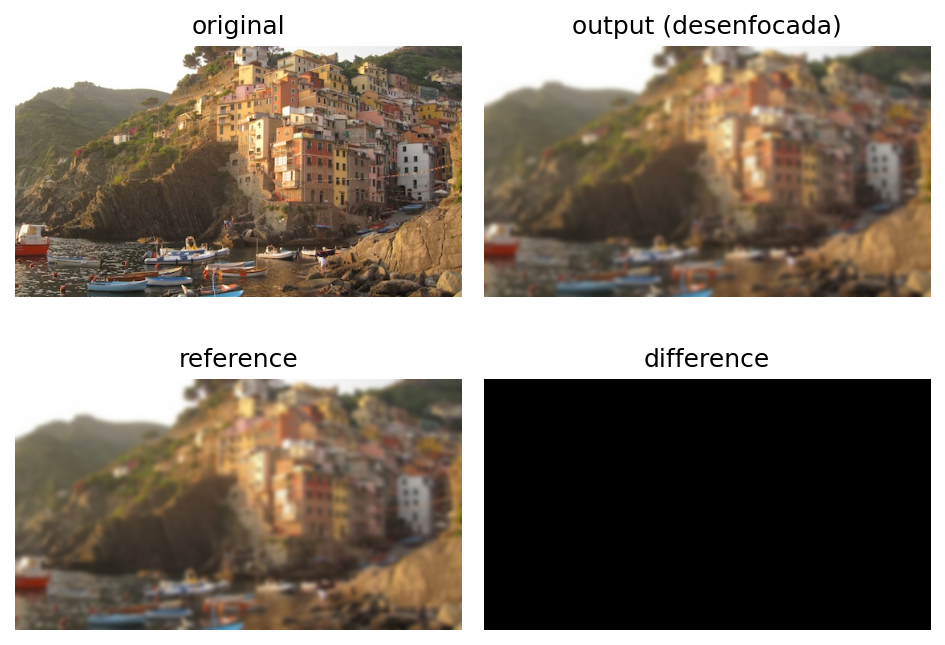

In [6]:
import os
import matplotlib.pyplot as plt

%cd /content/udacity-cs344-colab/build

imagenes = [
    ("original",   "../src/HW2/cinque_terre_small.jpg"),
    ("output (desenfocada)", "HW2_output.png"),
    ("reference",  "HW2_reference.png"),
    ("difference", "HW2_differenceImage.png"),
]

fig, ax = plt.subplots(2, 2, dpi=150)
for a, (titulo, ruta) in zip(ax.flat, imagenes):
    if os.path.exists(ruta):
        img = plt.imread(ruta)
        a.imshow(img, cmap="gray" if img.ndim == 2 else None)
    else:
        a.text(0.5, 0.5, "no existe", ha="center", va="center")
    a.set_title(titulo)
    a.axis("off")
plt.tight_layout()
plt.show()
